# 05. GA-G-CTGAN (Proposed Method)
**GA-Optimized G-CTGAN: An Automated Oversampling Framework for Imbalanced Data Classification**

This notebook implements the **proposed GA-G-CTGAN** method.

**Pipeline:**
1. GMM clustering on minority class (BIC-optimal k)
2. Pre-train CTGAN per cluster (once)
3. GA optimization → search per-cluster synthetic multiplier vector `[r1, ..., rk]`
   - `r_c` = synthetic samples to generate as a **multiplier of cluster minority size**
   - e.g. r_c=1.0 → generate n_min_c samples for cluster c
   - Fitness: 5-fold CV AUC (lightweight RF surrogate)
   - Constraint: total minority ratio ∈ [0.20, 0.50]
4. Generate synthetic data with GA-optimal multipliers

Results saved to `results/05_ga_gctgan_results.csv`.


## 0. Setup

In [1]:
import os
import time
import warnings
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

DATASET_DIR = "./datasets"
RESULTS_DIR = "./results"
os.makedirs(RESULTS_DIR, exist_ok=True)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATASET_NAMES = [
    "credit_default", "fraud_detection", "pima_diabetes", "ibm_attrition",
    "yeast_me2", "mammography", "abalone_19", "wine_quality",
    "ecoli", "pageblocks", "protein_homo",
]

CLASSIFIERS = ["RF", "LGBM", "MLP"]

# ── GA hyperparameters ─────────────────────────────────────────────────
# r_c = synthetic multiplier relative to cluster minority size
# n_syn_c = round(n_min_c * r_c)
# r_min=0.5 → generate at least 50% of cluster size
# r_max=3.0 → generate at most 300% of cluster size
GA_CONFIG = {
    "n_generations" : 20,
    "pop_size"      : 20,
    "crossover_prob": 0.9,
    "mutation_prob" : 0.1,
    "eta_c"         : 15.0,
    "eta_m"         : 20.0,
    "ratio_lb"      : 0.20,
    "ratio_ub"      : 0.50,
    "cv_folds"      : 5,
    "random_state"  : RANDOM_STATE,
}

print(f"Datasets    : {len(DATASET_NAMES)}")
print(f"Classifiers : {CLASSIFIERS}")
print(f"GA config   : {GA_CONFIG}")


Datasets    : 11
Classifiers : ['RF', 'LGBM', 'MLP']
GA config   : {'n_generations': 20, 'pop_size': 20, 'crossover_prob': 0.9, 'mutation_prob': 0.1, 'eta_c': 15.0, 'eta_m': 20.0, 'ratio_lb': 0.2, 'ratio_ub': 0.5, 'cv_folds': 5, 'random_state': 42}


## 1. Classifier & Evaluation

In [2]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score
from lightgbm import LGBMClassifier

def get_classifier(name, random_state=RANDOM_STATE):
    if name == "RF":
        return RandomForestClassifier(
            n_estimators=200, max_depth=10, min_samples_leaf=3,
            class_weight="balanced", random_state=random_state, n_jobs=-1,
        )
    elif name == "LGBM":
        return LGBMClassifier(
            n_estimators=100, learning_rate=0.05, num_leaves=31,
            class_weight="balanced", random_state=random_state, n_jobs=-1, verbose=-1,
        )
    elif name == "MLP":
        return MLPClassifier(
            hidden_layer_sizes=(128, 64), alpha=0.001,
            max_iter=300, random_state=random_state,
        )

def evaluate(model, X_test, y_test):
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = model.predict(X_test)
    return {
        "AUC"      : round(roc_auc_score(y_test, y_prob), 4),
        "F1"       : round(f1_score(y_test, y_pred, zero_division=0), 4),
        "Precision": round(precision_score(y_test, y_pred, zero_division=0), 4),
        "Recall"   : round(recall_score(y_test, y_pred, zero_division=0), 4),
    }

print("Ready.")


Ready.


## 2. GMM Clustering

In [3]:
from sklearn.mixture import GaussianMixture

def select_optimal_k(X_min, k_range=range(2, 11), random_state=RANDOM_STATE):
    bic_scores = {}
    for k in k_range:
        if len(X_min) < k * 2:
            break
        try:
            gmm = GaussianMixture(
                n_components=k, covariance_type="full",
                random_state=random_state, max_iter=200,
            )
            gmm.fit(X_min)
            bic_scores[k] = gmm.bic(X_min)
        except Exception:
            continue
    if not bic_scores:
        return 2, {}
    best_k = min(bic_scores, key=bic_scores.get)
    return best_k, bic_scores

print("Ready.")


Ready.


## 3. GA Optimization

In [4]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier as RFSurrogate
from ctgan import CTGAN


def compute_n_syn_per_cluster(X_min, labels, ratio_vec, best_k):
    """
    Compute per-cluster synthetic sample count.
    n_syn_c = round(n_min_c * ratio_vec[c])
    ratio_vec[c]: synthetic multiplier relative to cluster minority size.
    """
    n_syn_list = []
    for c in range(best_k):
        n_min_c = int((labels == c).sum())
        n_syn_c = max(0, int(np.round(n_min_c * ratio_vec[c])))
        n_syn_list.append(n_syn_c)
    return n_syn_list


def build_resampled_data(X_min, labels, X_maj, ratio_vec, best_k,
                         ctgan_models, random_state=RANDOM_STATE):
    n_syn_list = compute_n_syn_per_cluster(X_min, labels, ratio_vec, best_k)
    X_syn_list = []

    for c in range(best_k):
        n_syn = n_syn_list[c]
        if n_syn == 0 or ctgan_models.get(c) is None:
            continue
        X_cluster = X_min[labels == c]
        if len(X_cluster) < 2:
            continue
        try:
            X_syn_cl = ctgan_models[c].sample(n_syn).values.astype(float)
            X_syn_list.append(X_syn_cl)
        except Exception:
            continue

    if not X_syn_list:
        return (np.vstack([X_maj, X_min]),
                np.concatenate([np.zeros(len(X_maj)),
                                np.ones(len(X_min))]).astype(int))

    X_syn = np.vstack(X_syn_list)
    X_out = np.vstack([X_maj, X_min, X_syn])
    y_out = np.concatenate([
        np.zeros(len(X_maj)),
        np.ones(len(X_min)),
        np.ones(len(X_syn)),
    ]).astype(int)
    return X_out, y_out


def fitness_function(ratio_vec, X_min, labels, X_maj, best_k,
                     ctgan_models, cv_folds=5, random_state=RANDOM_STATE):
    """
    Fitness = mean 5-fold CV AUC (RF surrogate).
    Constraint: total minority ratio ∈ [ratio_lb, ratio_ub].
    """
    n_syn_list  = compute_n_syn_per_cluster(X_min, labels, ratio_vec, best_k)
    total_syn   = sum(n_syn_list)
    n_min_total = len(X_min) + total_syn
    n_maj       = len(X_maj)
    total_ratio = n_min_total / (n_min_total + n_maj)

    if not (GA_CONFIG["ratio_lb"] <= total_ratio <= GA_CONFIG["ratio_ub"]):
        return 0.0

    X_res, y_res = build_resampled_data(
        X_min, labels, X_maj, ratio_vec, best_k, ctgan_models, random_state
    )

    if y_res.sum() < cv_folds or (y_res == 0).sum() < cv_folds:
        return 0.0

    surrogate = RFSurrogate(
        n_estimators=50, max_depth=5,
        class_weight="balanced", random_state=random_state, n_jobs=-1,
    )
    try:
        scores = cross_val_score(
            surrogate, X_res, y_res,
            cv=StratifiedKFold(n_splits=cv_folds, shuffle=True,
                               random_state=random_state),
            scoring="roc_auc", n_jobs=-1,
        )
        return float(scores.mean())
    except Exception:
        return 0.0


def sbx_crossover(p1, p2, eta_c, r_min, r_max, rng):
    c1, c2 = p1.copy(), p2.copy()
    for i in range(len(p1)):
        if rng.random() > 0.5:
            continue
        u = rng.random()
        beta = (2*u)**(1/(eta_c+1)) if u <= 0.5 else (1/(2*(1-u)))**(1/(eta_c+1))
        c1[i] = np.clip(0.5*((1+beta)*p1[i]+(1-beta)*p2[i]), r_min, r_max)
        c2[i] = np.clip(0.5*((1-beta)*p1[i]+(1+beta)*p2[i]), r_min, r_max)
    return c1, c2


def polynomial_mutation(ind, eta_m, r_min, r_max, prob, rng):
    result = ind.copy()
    delta  = r_max - r_min
    for i in range(len(result)):
        if rng.random() < prob:
            u = rng.random()
            dq = (2*u)**(1/(eta_m+1))-1 if u < 0.5 else 1-(2*(1-u))**(1/(eta_m+1))
            result[i] = np.clip(result[i] + dq * delta, r_min, r_max)
    return result


def tournament_selection(population, fitness_scores, k=2, rng=None):
    candidates = rng.choice(len(population), size=k, replace=False)
    best = candidates[np.argmax([fitness_scores[c] for c in candidates])]
    return population[best].copy()


def run_ga(X_min, labels, X_maj, best_k, ctgan_models, config=GA_CONFIG):
    rng      = np.random.default_rng(config["random_state"])
    r_min    = config["r_min"]
    r_max    = config["r_max"]
    pop_size = config["pop_size"]
    n_gen    = config["n_generations"]

    population      = [rng.uniform(r_min, r_max, best_k) for _ in range(pop_size)]
    best_individual = None
    best_fitness    = -1.0
    convergence     = []

    for gen in range(n_gen):
        fitness_scores = [
            fitness_function(ind, X_min, labels, X_maj, best_k, ctgan_models,
                             config["cv_folds"], config["random_state"])
            for ind in population
        ]

        gen_best_idx = int(np.argmax(fitness_scores))
        gen_best_fit = fitness_scores[gen_best_idx]
        convergence.append(gen_best_fit)

        if gen_best_fit > best_fitness:
            best_fitness    = gen_best_fit
            best_individual = population[gen_best_idx].copy()

        print(f"    Gen {gen+1:>3}/{n_gen}  best_AUC={gen_best_fit:.4f}  "
              f"global_best={best_fitness:.4f}  "
              f"ratio_vec={np.round(best_individual,3)}")

        # Next generation
        new_pop = [best_individual.copy()]   # elitism
        while len(new_pop) < pop_size:
            p1 = tournament_selection(population, fitness_scores, rng=rng)
            p2 = tournament_selection(population, fitness_scores, rng=rng)
            if rng.random() < config["crossover_prob"]:
                c1, c2 = sbx_crossover(p1, p2, config["eta_c"], r_min, r_max, rng)
            else:
                c1, c2 = p1.copy(), p2.copy()
            c1 = polynomial_mutation(c1, config["eta_m"], r_min, r_max,
                                     config["mutation_prob"], rng)
            c2 = polynomial_mutation(c2, config["eta_m"], r_min, r_max,
                                     config["mutation_prob"], rng)
            new_pop.extend([c1, c2])
        population = new_pop[:pop_size]

    return best_individual, best_fitness, convergence


print("GA functions ready.")


GA functions ready.


## 4. GA-G-CTGAN Pipeline

In [11]:
def apply_ga_gctgan(X_train, y_train, random_state=RANDOM_STATE):
    X_min = X_train[y_train == 1].astype(float)
    X_maj = X_train[y_train == 0].astype(float)
    n_min = len(X_min)
    n_maj = len(X_maj)
    current_ratio = n_min / (n_min + n_maj)

    # Step 1: GMM clustering
    best_k, bic_scores = select_optimal_k(X_min, random_state=random_state)
    gmm = GaussianMixture(
        n_components=best_k, covariance_type="full",
        random_state=random_state, max_iter=200,
    )
    gmm.fit(X_min)
    labels = gmm.predict(X_min)
    cluster_sizes = np.bincount(labels)
    print(f"  GMM: best_k={best_k}  cluster_sizes={cluster_sizes.tolist()}")

    # ── Dynamic r range ────────────────────────────────────────────────
    ratio_ub = GA_CONFIG["ratio_ub"]
    ratio_lb = max(GA_CONFIG["ratio_lb"], current_ratio + 0.01)
    
    # r_max from ratio_ub constraint
    r_max_ratio = (ratio_ub * n_maj / (1 - ratio_ub)) / n_min - 1
    
    # r_max from CTGAN quality constraint:
    # total synthetic ≤ 10× minority training size
    # n_min * r_max ≤ 10 * n_min  →  r_max ≤ 10
    CTGAN_MAX_MULTIPLIER = 10.0
    r_max = min(r_max_ratio, CTGAN_MAX_MULTIPLIER)
    r_max = max(r_max, 0.5)
    
    # r_min from ratio_lb constraint
    r_min = max(0.01, (ratio_lb * n_maj / (1 - ratio_lb)) / n_min - 1)
    r_min = min(r_min, r_max - 0.1)

    print(f"  current_ratio={current_ratio:.4f}  "
          f"r_range=[{r_min:.3f}, {r_max:.3f}]  "
          f"ratio_constraint=[{ratio_lb:.3f}, {ratio_ub:.3f}]")

    # Update config
    config = {**GA_CONFIG, "r_min": r_min, "r_max": r_max, "ratio_lb": ratio_lb}

    # Step 2: Pre-train CTGAN per cluster (once)
    print(f"  Pre-training {best_k} CTGAN models...")
    ctgan_models = {}
    for c in range(best_k):
        X_cluster = X_min[labels == c]
        if len(X_cluster) < 2:
            ctgan_models[c] = None
            continue
        cols    = [f"f{i}" for i in range(X_cluster.shape[1])]
        X_cl_df = pd.DataFrame(X_cluster, columns=cols)
        try:
            model = CTGAN(epochs=100, verbose=False)
            model.fit(X_cl_df)
            ctgan_models[c] = model
            print(f"    Cluster {c}: n={len(X_cluster)}  ✓")
        except Exception as e:
            ctgan_models[c] = None
            print(f"    Cluster {c}: failed ({e})")

    # Step 3: GA optimization
    print(f"  Running GA ({config['n_generations']}gen × {config['pop_size']}pop)...")
    t_ga = time.time()
    best_ratio_vec, best_auc, convergence = run_ga(
        X_min, labels, X_maj, best_k, ctgan_models, config
    )
    ga_time = round(time.time() - t_ga, 2)
    print(f"  GA done [{ga_time:.1f}s]  best_CV_AUC={best_auc:.4f}")
    print(f"  Optimal multipliers: {np.round(best_ratio_vec, 4)}")

    # Step 4: Generate with GA-optimal multipliers
    X_out, y_out = build_resampled_data(
        X_min, labels, X_maj, best_ratio_vec, best_k, ctgan_models, random_state
    )

    info = {
        "best_k"        : best_k,
        "bic_scores"    : bic_scores,
        "cluster_sizes" : cluster_sizes.tolist(),
        "r_min"         : r_min,
        "r_max"         : r_max,
        "best_ratio_vec": best_ratio_vec.tolist(),
        "best_cv_auc"   : best_auc,
        "convergence"   : convergence,
        "ga_time"       : ga_time,
    }
    return X_out, y_out, info

print("Pipeline ready.")

Pipeline ready.


## 5. Main Experiment Loop

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

results  = []
ga_infos = {}
TOTAL    = len(DATASET_NAMES) * len(CLASSIFIERS)
done     = 0

for ds_name in DATASET_NAMES:
    path = os.path.join(DATASET_DIR, f"{ds_name}.csv")
    if not os.path.exists(path):
        print(f"[SKIP] {ds_name}")
        done += len(CLASSIFIERS)
        continue

    df = pd.read_csv(path)
    X  = df.drop(columns=["target"]).values.astype(float)
    y  = df["target"].values.astype(int)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE
    )
    scaler  = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test  = scaler.transform(X_test)

    print(f"\n{'='*60}")
    print(f"Dataset : {ds_name}  |  n_train={len(X_train):,}  |  "
          f"minority={y_train.mean():.2%}")
    print(f"{'='*60}")

    t0 = time.time()
    try:
        X_res, y_res, info = apply_ga_gctgan(X_train.copy(), y_train.copy())
        total_time = round(time.time() - t0, 2)
        ratio_res  = round((y_res == 1).sum() / len(y_res), 4)
        ga_infos[ds_name] = info
        print(f"  Result: n_resampled={len(y_res):,}  minority={ratio_res:.2%}  "
              f"[{total_time:.1f}s]")
    except Exception as e:
        print(f"  GA-G-CTGAN failed: {e}")
        done += len(CLASSIFIERS)
        continue

    for clf_name in CLASSIFIERS:
        done += 1
        progress = f"[{done:>4}/{TOTAL}]"
        clf = get_classifier(clf_name)
        t1  = time.time()
        try:
            clf.fit(X_res, y_res)
            train_time = round(time.time() - t1, 2)
            metrics    = evaluate(clf, X_test, y_test)
        except Exception as e:
            print(f"  {progress} {ds_name} | GA-G-CTGAN | {clf_name} — Failed: {e}")
            continue

        row = {
            "dataset"          : ds_name,
            "oversampling"     : "GA-G-CTGAN",
            "classifier"       : clf_name,
            "n_train_resampled": len(y_res),
            "minority_ratio"   : ratio_res,
            "best_k"           : info["best_k"],
            "best_cv_auc"      : info["best_cv_auc"],
            "ga_time"          : info["ga_time"],
            "train_time"       : train_time,
            **metrics,
        }
        results.append(row)
        print(f"  {progress} {ds_name} | GA-G-CTGAN | {clf_name:<7} | "
              f"AUC={metrics['AUC']:.4f}  F1={metrics['F1']:.4f}  [{train_time:.1f}s]")

print("\nExperiment complete.")



Dataset : credit_default  |  n_train=21,000  |  minority=22.12%
  GMM: best_k=9  cluster_sizes=[378, 539, 461, 1040, 335, 181, 478, 609, 624]
  current_ratio=0.2212  r_range=[0.059, 2.521]  ratio_constraint=[0.231, 0.500]
  Pre-training 9 CTGAN models...
    Cluster 0: n=378  ✓
    Cluster 1: n=539  ✓
    Cluster 2: n=461  ✓
    Cluster 3: n=1040  ✓
    Cluster 4: n=335  ✓
    Cluster 5: n=181  ✓
    Cluster 6: n=478  ✓
    Cluster 7: n=609  ✓
    Cluster 8: n=624  ✓
  Running GA (20gen × 20pop)...
    Gen   1/20  best_AUC=0.9065  global_best=0.9065  ratio_vec=[0.115 2.419 1.246 1.986 0.263 1.257 1.267 2.368 1.467]
    Gen   2/20  best_AUC=0.9067  global_best=0.9067  ratio_vec=[0.115 2.419 1.246 1.986 0.263 1.257 1.267 2.368 1.467]
    Gen   3/20  best_AUC=0.9070  global_best=0.9070  ratio_vec=[0.117 2.419 1.246 2.066 0.081 1.257 1.288 2.478 1.466]
    Gen   4/20  best_AUC=0.9074  global_best=0.9074  ratio_vec=[0.117 2.419 1.246 2.066 0.081 1.257 1.288 2.478 1.466]
    Gen   5/20  bes

## 6. GA Convergence Analysis

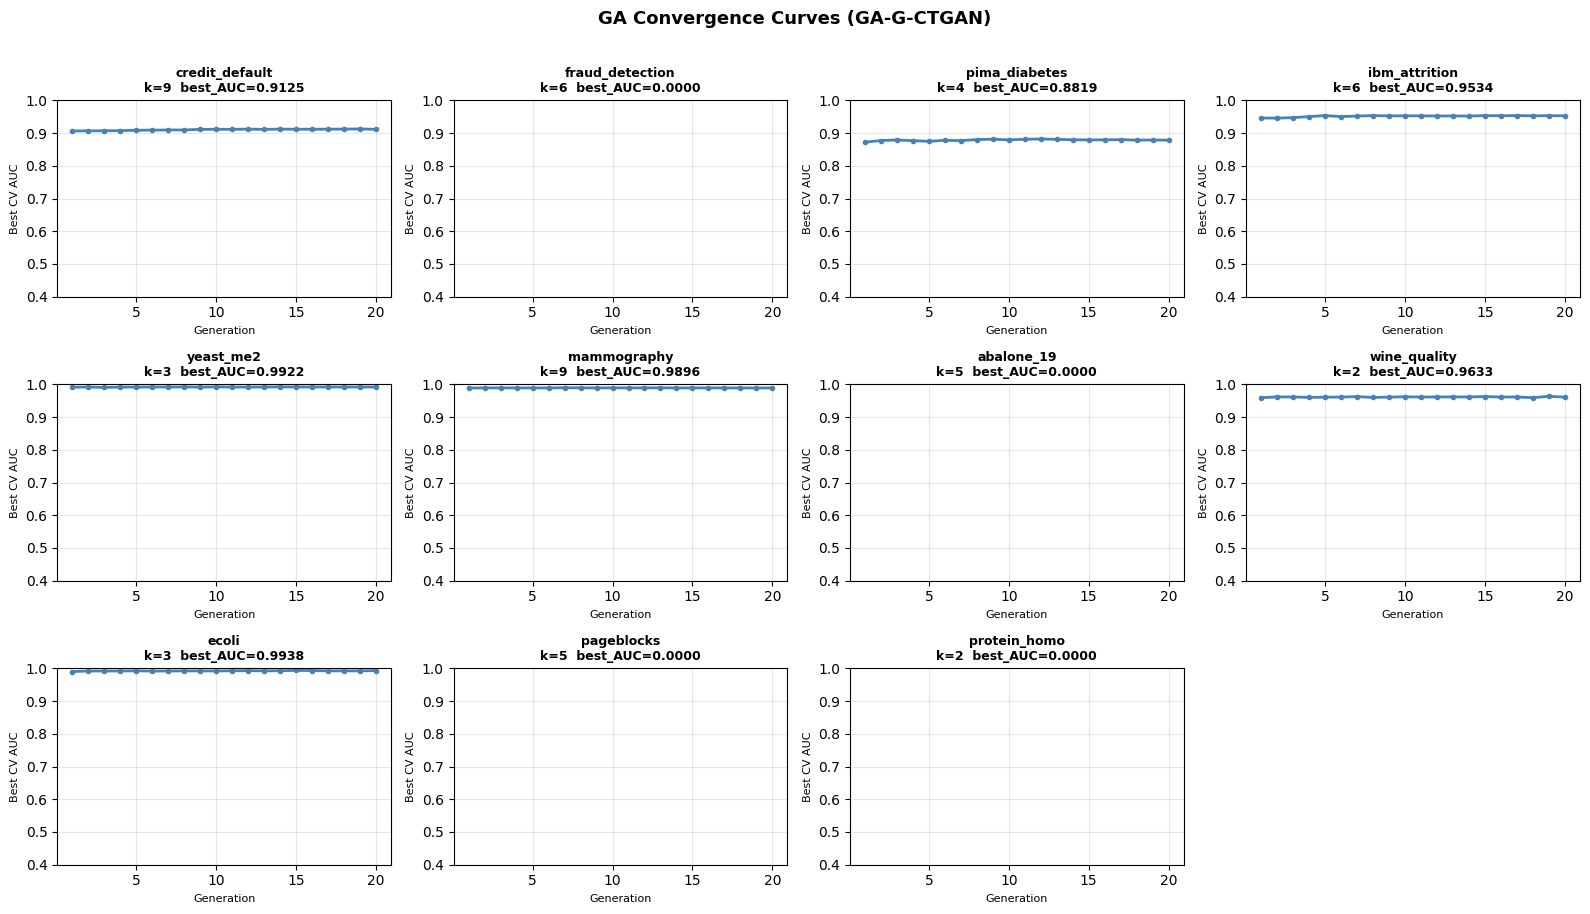

Figure saved → ./results\05_ga_convergence.png

GA-Optimized Multipliers by Dataset:
Dataset                  k   CV_AUC  Multiplier Vector
-----------------------------------------------------------------
  credit_default           9   0.9125  [0.101 2.521 1.44  2.514 0.101 1.449 1.504 2.312 1.557]
  fraud_detection          6   0.0000  [9.977 9.944 9.986 9.97  9.909 9.998]
  pima_diabetes            4   0.8819  [0.736 0.596 0.617 0.69 ]
  ibm_attrition            6   0.9534  [3.53  2.811 3.173 1.702 4.199 3.867]
  yeast_me2                3   0.9922  [9.051 6.321 9.968]
  mammography              9   0.9896  [ 9.914  9.791  9.869  9.675 10.     9.93   9.89   9.61   9.733]
  abalone_19               5   0.0000  [9.977 9.944 9.986 9.97  9.909]
  wine_quality             2   0.9633  [8.799 9.986]
  ecoli                    3   0.9938  [5.674 1.617 7.575]
  pageblocks               5   0.0000  [9.977 9.944 9.986 9.97  9.909]
  protein_homo             2   0.0000  [9.977 9.944]


In [13]:
import matplotlib.pyplot as plt

n_plots = len(ga_infos)
if n_plots > 0:
    ncols = min(4, n_plots)
    nrows = (n_plots + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3*nrows))
    axes = np.array(axes).flatten() if n_plots > 1 else [axes]

    for ax, (ds, info) in zip(axes, ga_infos.items()):
        conv = info["convergence"]
        ax.plot(range(1, len(conv)+1), conv,
                marker='o', markersize=3, color='steelblue', linewidth=2)
        ax.set_title(f"{ds}\nk={info['best_k']}  best_AUC={info['best_cv_auc']:.4f}",
                     fontsize=9, fontweight='bold')
        ax.set_xlabel("Generation", fontsize=8)
        ax.set_ylabel("Best CV AUC", fontsize=8)
        ax.set_ylim(0.4, 1.0)
        ax.grid(True, alpha=0.3)

    for ax in axes[len(ga_infos):]:
        ax.set_visible(False)

    plt.suptitle("GA Convergence Curves (GA-G-CTGAN)",
                 fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    fig_path = os.path.join(RESULTS_DIR, "05_ga_convergence.png")
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Figure saved → {fig_path}")

print("\nGA-Optimized Multipliers by Dataset:")
print(f"{'Dataset':<22} {'k':>3}  {'CV_AUC':>7}  Multiplier Vector")
print("-" * 65)
for ds, info in ga_infos.items():
    rv = np.round(info["best_ratio_vec"], 3)
    print(f"  {ds:<22} {info['best_k']:>3}  "
          f"{info['best_cv_auc']:>7.4f}  {rv}")


## 7. Save Results

In [14]:
results_df = pd.DataFrame(results)
save_path  = os.path.join(RESULTS_DIR, "05_ga_gctgan_results.csv")
results_df.to_csv(save_path, index=False)
print(f"Results saved → {save_path}")
print(f"Total rows    : {len(results_df)}")
print()
print(results_df.groupby("classifier")["AUC"].mean().round(4).to_string())


Results saved → ./results\05_ga_gctgan_results.csv
Total rows    : 33

classifier
LGBM    0.8919
MLP     0.8611
RF      0.8939


## 8. Compare All Methods

Mean AUC (averaged over all datasets):
classifier      LGBM     MLP      RF
oversampling                        
SMOTE         0.8935  0.8604  0.8954
ADASYN        0.8903  0.8566  0.8950
G-SMOTE       0.8950  0.8561  0.8974
CTGAN         0.8872  0.8701  0.8815
TVAE          0.8908  0.8573  0.8844
G-CTGAN       0.8798  0.8736  0.8836
GA-G-CTGAN    0.8919  0.8611  0.8939


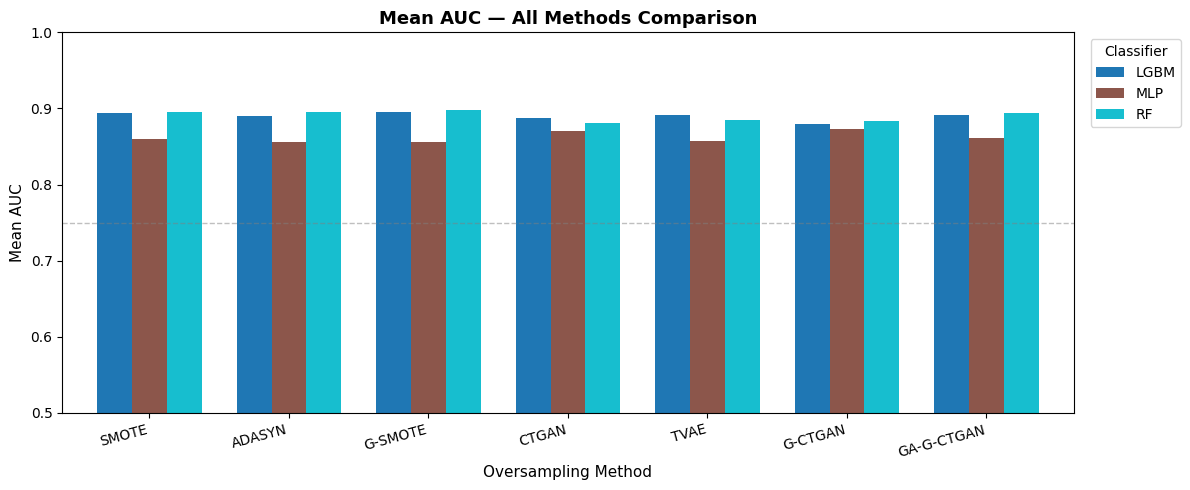

Figure saved → ./results\05_all_methods_comparison.png


In [15]:
dfs = []
for fname in ["02_baselines_results.csv",
              "04_gctgan_results.csv",
              "05_ga_gctgan_results.csv"]:
    fpath = os.path.join(RESULTS_DIR, fname)
    if os.path.exists(fpath):
        dfs.append(pd.read_csv(fpath))
    else:
        print(f"Not found: {fname}")

if dfs:
    combined_df = pd.concat(dfs, ignore_index=True)
    METHOD_ORDER = ["None", "SMOTE", "ADASYN", "G-SMOTE",
                    "CTGAN", "TVAE", "G-CTGAN", "GA-G-CTGAN"]
    pivot = (combined_df
             .groupby(["oversampling", "classifier"])["AUC"]
             .mean()
             .unstack())
    pivot = pivot.reindex([m for m in METHOD_ORDER if m in pivot.index])

    print("Mean AUC (averaged over all datasets):")
    print(pivot.round(4).to_string())

    fig, ax = plt.subplots(figsize=(12, 5))
    pivot.plot(kind="bar", ax=ax, width=0.75, colormap="tab10")
    ax.set_title("Mean AUC — All Methods Comparison",
                 fontsize=13, fontweight="bold")
    ax.set_xlabel("Oversampling Method", fontsize=11)
    ax.set_ylabel("Mean AUC", fontsize=11)
    ax.set_ylim(0.5, 1.0)
    ax.axhline(0.75, color="gray", linestyle="--", linewidth=1, alpha=0.5)
    ax.legend(title="Classifier", bbox_to_anchor=(1.01, 1), loc="upper left")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha="right")
    plt.tight_layout()
    fig_path = os.path.join(RESULTS_DIR, "05_all_methods_comparison.png")
    plt.savefig(fig_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Figure saved → {fig_path}")


In [16]:
# GA-G-CTGAN: keep only applicable datasets (IR ≤ 50, minority n ≥ 100)
GA_APPLICABLE = [
    "credit_default", "pima_diabetes", "ibm_attrition",
    "yeast_me2", "wine_quality", "ecoli"
]

ga_df = pd.read_csv("./results/05_ga_gctgan_results.csv")
ga_df = ga_df[ga_df["dataset"].isin(GA_APPLICABLE)]

In [17]:
ga_df

,dataset,oversampling,classifier,n_train_resampled,minority_ratio,best_k,best_cv_auc,ga_time,train_time,AUC,F1,Precision,Recall
0,credit_default,GA-G-CTGAN,RF,29071,0.4374,9,0.912525,714.12,1.48,0.7650,0.4832,0.6188,0.3963
1,credit_default,GA-G-CTGAN,LGBM,29071,0.4374,9,0.912525,714.12,0.40,0.7785,0.4777,0.6394,0.3812
2,credit_default,GA-G-CTGAN,MLP,29071,0.4374,9,0.912525,714.12,88.46,0.7006,0.4355,0.4903,0.3918
6,pima_diabetes,GA-G-CTGAN,RF,661,0.4705,4,0.881929,129.24,0.30,0.8187,0.6282,0.6533,0.6049
7,pima_diabetes,GA-G-CTGAN,LGBM,661,0.4705,4,0.881929,129.24,0.13,0.8051,0.6225,0.6714,0.5802
8,pima_diabetes,GA-G-CTGAN,MLP,661,0.4705,4,0.881929,129.24,1.36,0.7430,0.5157,0.5256,0.5062
9,ibm_attrition,GA-G-CTGAN,RF,1568,0.4496,6,0.953422,379.16,0.31,0.7650,0.1978,0.4500,0.1268
10,ibm_attrition,GA-G-CTGAN,LGBM,1568,0.4496,6,0.953422,379.16,0.26,0.7646,0.3333,0.5484,0.2394
11,ibm_attrition,GA-G-CTGAN,MLP,1568,0.4496,6,0.953422,379.16,1.12,0.7204,0.4060,0.4355,0.3803
12,yeast_me2,GA-G-CTGAN,RF,1358,0.2622,3,0.992163,91.95,0.31,0.9318,0.1905,0.3333,0.1333
